## Overview
This notebook demonstrates a initial proof of concept for a smart intersection manager. Specifically, it demonstrates how machine learning can be used to monitor activity at the intersection by using computer vision to detect vehicles and pedestrians in camera footage. Our system can use information about vehicles and pedestrians present at the intersection to deduce the state of the intersection and determine what actions to take to maximize the safety and utility of the intersection for everyone present.

## 1. Install Dependencies

In [ ]:
!pip install ultralytics --upgrade -q
!pip install Pillow matplotlib requests -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.8 MB/s eta 0:00:00


## 2. Import Libraries

In [ ]:
import os
import requests
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np
import gradio as gr

from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 3. Load the YOLO26 Model
We have chosen to use the <b>Nano</b> model for this POC because it is the most appropriate model for edge computing. <br>
This makes it the ideal candidate to be used for this application where the compute hardware available on-site is very limited.

In [ ]:
# Choose model size: 'n' (nano/fastest) to 'x' (xlarge/most accurate)
MODEL_SIZE = "n"  # change to 's', 'm', 'l', or 'x' for higher accuracy

model = YOLO(f"yolo26{MODEL_SIZE}.pt")  # auto-downloads on first run

print(f" YOLO26{MODEL_SIZE.upper()} loaded successfully!")
print(f" Model task: {model.task}")
print(f" Number of classes: {len(model.names)}")

 YOLO26N loaded successfully!
 Model task: detect
 Number of classes: 80


## 4. Define Vehicle Classes

COCO includes several vehicle-related classes. <br>
We'll filter results to only show vehicles and people.

In [ ]:
# COCO class IDs for vehicles
VEHICLE_CLASS_NAMES = {"car", "truck", "bus", "motorcycle", "bicycle", "person"}

# Map class names to their COCO IDs
vehicle_class_ids = {
    cls_id: cls_name
    for cls_id, cls_name in model.names.items()
    if cls_name in VEHICLE_CLASS_NAMES
}

print("Vehicle classes detected:")
for cls_id, cls_name in sorted(vehicle_class_ids.items()):
    print(f"   [{cls_id}] {cls_name}")

Vehicle classes detected:
   [0] person
   [1] bicycle
   [2] car
   [3] motorcycle
   [5] bus
   [7] truck


## 5. Download Sample Images

We'll use a few Toronto traffic/street images for testing.

In [ ]:
# Sample traffic camera images
# Download from City of Toronto Open Data website.
SAMPLE_IMAGES = {
    "toronto-yorkst-bremnerblvd.jpg" : "https://opendata.toronto.ca/transportation/tmc/rescucameraimages/CameraImages/loc8001.jpg",
    "toronto-lsimcoe-bremnerblvd.jpg" : "https://opendata.toronto.ca/transportation/tmc/rescucameraimages/CameraImages/loc8002.jpg",
    "toronto-richmondw-spadina.jpg" : "https://opendata.toronto.ca/transportation/tmc/rescucameraimages/CameraImages/loc8020.jpg",
    "toronto-parliament-king.jpg" : "https://opendata.toronto.ca/transportation/tmc/rescucameraimages/CameraImages/loc8010.jpg"
}

os.makedirs("images", exist_ok=True)

for filename, url in SAMPLE_IMAGES.items():
    dest = Path("images") / filename
    if not dest.exists():
        print(f"Downloading {filename}...")
        response = requests.get(url, timeout=10)
        dest.write_bytes(response.content)
        print(f" Saved to {dest}")
    else:
        print(f" {filename} already exists.")

# You can also add your own images:
# Place any .jpg / .png files into the 'images/' folder

 Saved to images/toronto-yorkst-bremnerblvd.jpg
 Saved to images/toronto-lsimcoe-bremnerblvd.jpg
 Saved to images/toronto-richmondw-spadina.jpg
 Saved to images/toronto-parliament-king.jpg


## 6. Run Car Detection

Define a function to detect pedestrians and vehicles in input images.

In [ ]:
def detect_vehicles(image_path, conf_threshold=0.35):
    """
    Run YOLO26 on an image and return vehicle detections.

    Args:
        image_path (str): Path to input image.
        conf_threshold (float): Minimum confidence score (0–1).

    Returns:
        results: YOLO result object
        vehicle_boxes: list of (x1, y1, x2, y2, conf, class_name)
    """
    results = model.predict(
        source=image_path,
        conf=conf_threshold,
        verbose=False,
    )

    result = results[0]
    vehicle_boxes = []

    for box in result.boxes:
        cls_id = int(box.cls[0].item())
        cls_name = model.names[cls_id]

        if cls_name in VEHICLE_CLASS_NAMES:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            conf = float(box.conf[0].item())
            vehicle_boxes.append((x1, y1, x2, y2, conf, cls_name))

    return result, vehicle_boxes

print("detect_vehicles() function ready.")

detect_vehicles() function ready.


## 7. Visualize Results
Define a function to display results and save a copy of the annotated images as a JPG.

In [ ]:
# Color map for different vehicle types
CLASS_COLORS = {
    "car":        "#00BFFF",
    "truck":      "#FF6347",
    "bus":        "#FFD700",
    "motorcycle": "#7CFC00",
    "bicycle":    "#DA70D6",
    "person":     "#DA70D6",
}

def visualize_detections(image_path, vehicle_boxes, title=""):
    """
    Draw bounding boxes on the image and display it.
    """
    img = Image.open(image_path).convert("RGB")
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    ax.imshow(img)
    ax.axis("off")

    for (x1, y1, x2, y2, conf, cls_name) in vehicle_boxes:
        color = CLASS_COLORS.get(cls_name, "white")
        w, h = x2 - x1, y2 - y1

        rect = patches.FancyBboxPatch(
            (x1, y1), w, h,
            linewidth=2,
            edgecolor=color,
            facecolor="none",
            boxstyle="round,pad=1",
        )
        ax.add_patch(rect)

        label = f"{cls_name} {conf:.0%}"
        ax.text(
            x1 + 4, y1 - 6, label,
            color="white",
            fontsize=9, fontweight="bold",
            bbox=dict(facecolor=color, alpha=0.85, pad=2, edgecolor="none"),
        )

    n = len(vehicle_boxes)
    counts = {}
    for *_, cls_name in vehicle_boxes:
        counts[cls_name] = counts.get(cls_name, 0) + 1
    count_str = ", ".join(f"{v} {k}(s)" for k, v in counts.items())

    ax.set_title(
        f"{title} — {n} vehicle(s) detected" + (f": {count_str}" if count_str else ""),
        fontsize=13, pad=10
    )
    plt.tight_layout()
    plt.savefig(f"{title}")
    plt.show()

print("visualize_detections() function ready.")

visualize_detections() function ready.


## 8. Run on All Sample Images
Detect vehicles and pedestrians in downloaded sample images.


 Processing: toronto-lsimcoe-bremnerblvd.jpg
   Found 6 vehicle(s):
   • bus           conf=0.72  bbox=[0,59,17,92]
   • bus           conf=0.67  bbox=[22,65,66,106]
   • car           conf=0.62  bbox=[0,90,28,114]
   • car           conf=0.61  bbox=[64,79,90,101]
   • person        conf=0.41  bbox=[224,79,231,97]
   • car           conf=0.38  bbox=[18,58,27,63]


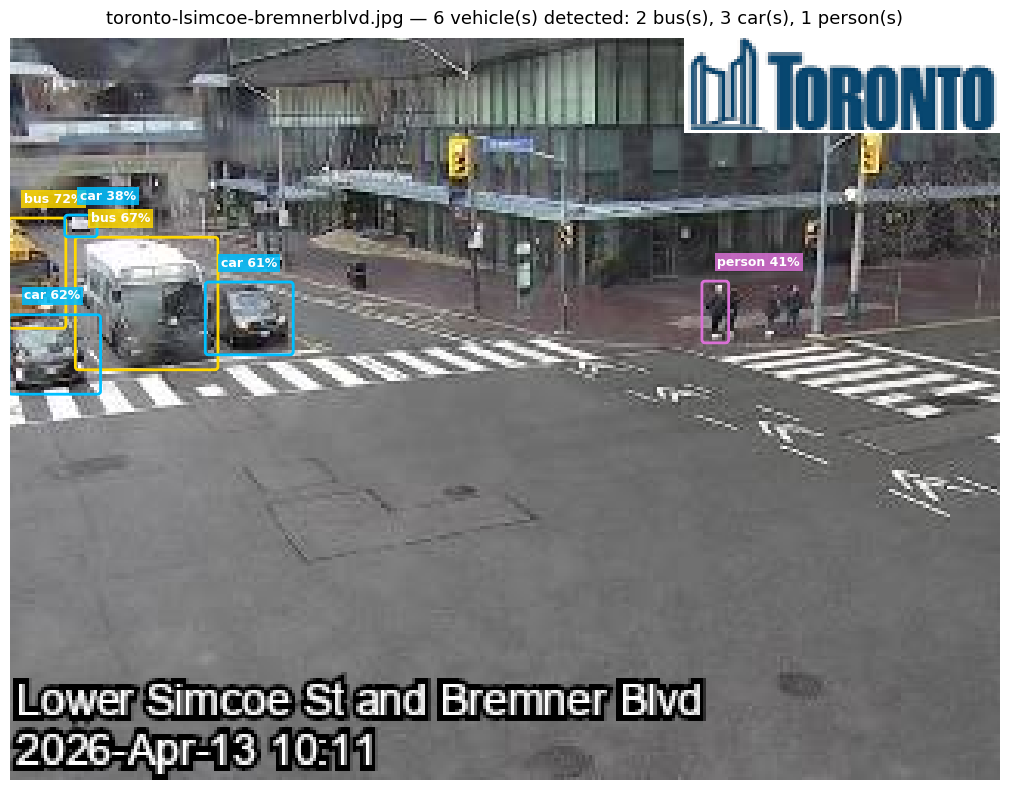


 Processing: toronto-parliament-king.jpg
   Found 1 vehicle(s):
   • car           conf=0.36  bbox=[46,68,57,76]


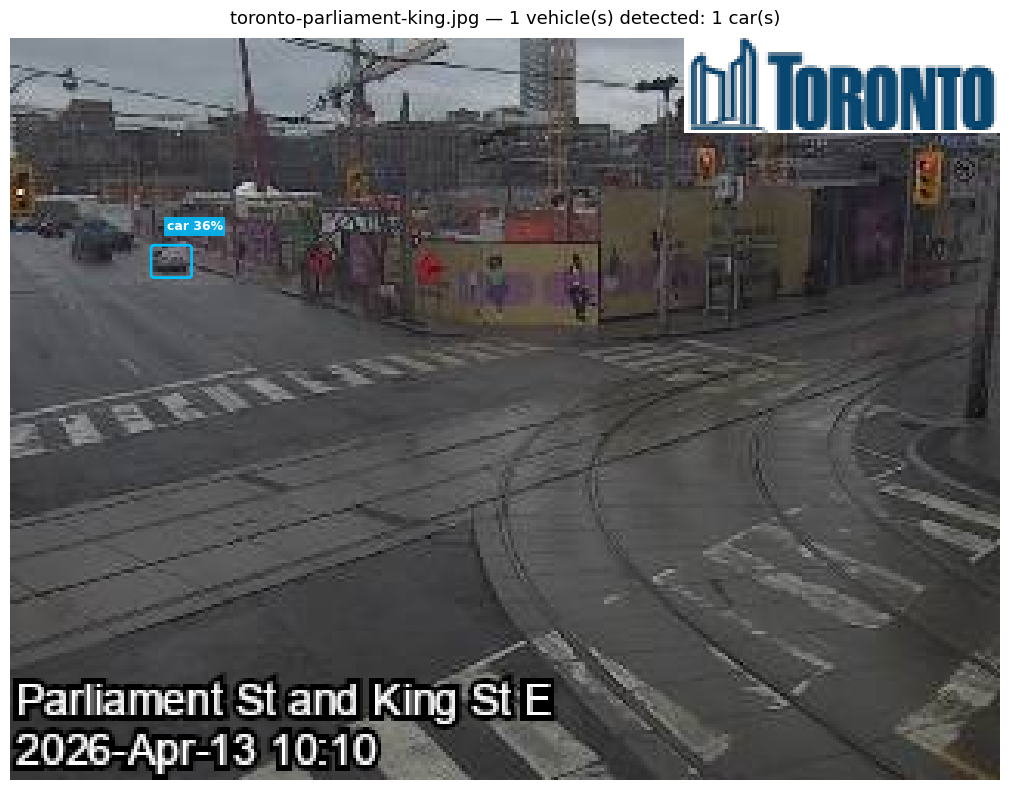


 Processing: toronto-richmondw-spadina.jpg
   Found 4 vehicle(s):
   • car           conf=0.88  bbox=[0,82,74,114]
   • truck         conf=0.85  bbox=[93,50,192,100]
   • car           conf=0.77  bbox=[195,50,215,68]
   • car           conf=0.55  bbox=[192,32,206,43]


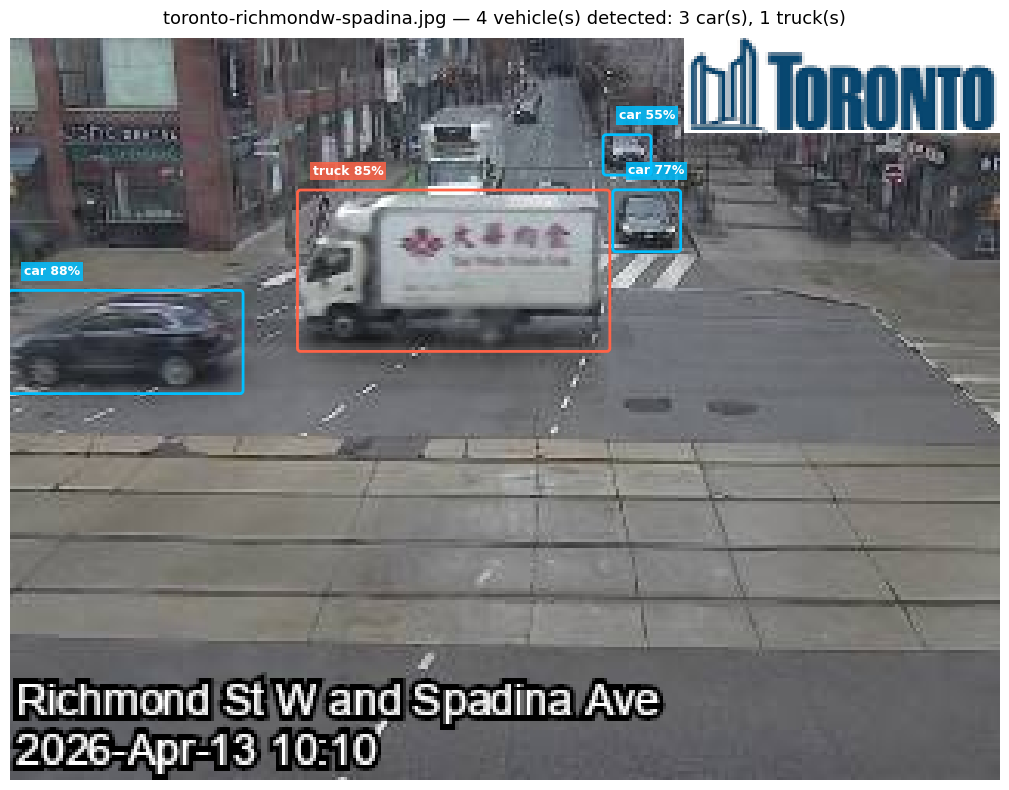


 Processing: toronto-yorkst-bremnerblvd.jpg
   Found 1 vehicle(s):
   • car           conf=0.79  bbox=[6,77,38,98]


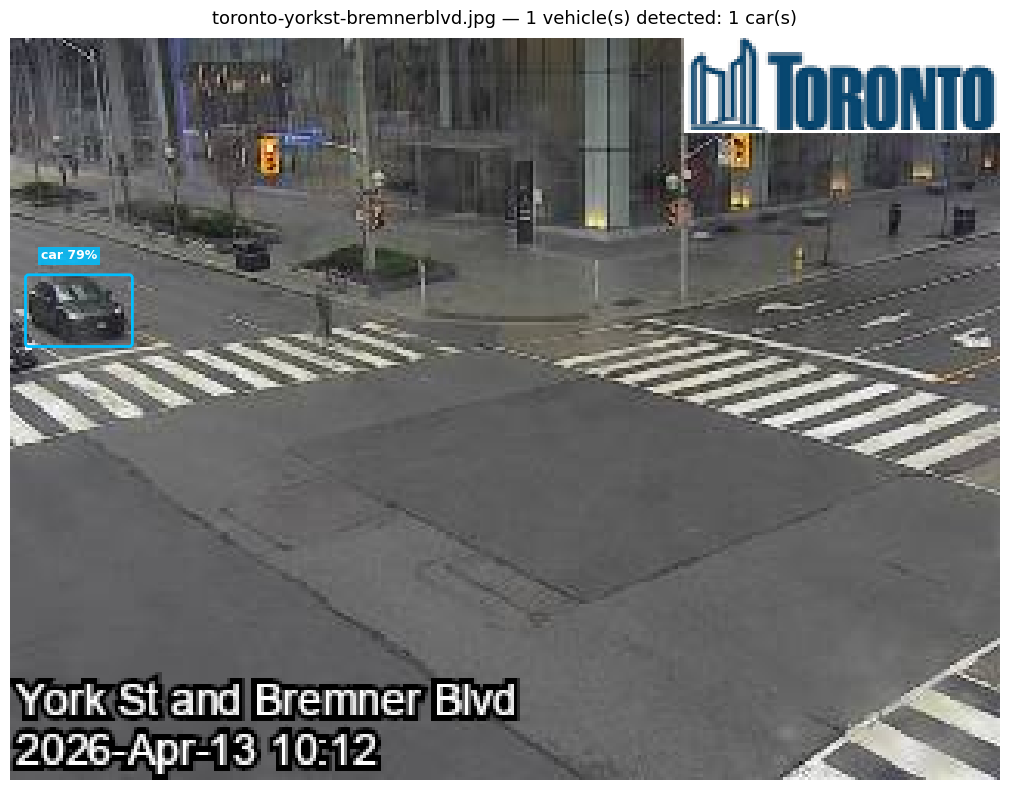

In [ ]:
CONFIDENCE_THRESHOLD = 0.35  # adjust between 0.1 (lenient) and 0.8 (strict)

image_files = list(Path("images").glob("*.jpg")) + list(Path("images").glob("*.png"))

if not image_files:
    print("No images found in 'images/' folder. Please add some images and rerun.")
else:
    for img_path in sorted(image_files):
        print(f"\n Processing: {img_path.name}")
        result, boxes = detect_vehicles(img_path, conf_threshold=CONFIDENCE_THRESHOLD)

        if boxes:
            print(f"   Found {len(boxes)} vehicle(s):")
            for (x1, y1, x2, y2, conf, cls_name) in boxes:
                print(f"   • {cls_name:12s}  conf={conf:.2f}  bbox=[{x1:.0f},{y1:.0f},{x2:.0f},{y2:.0f}]")
        else:
            print("   No vehicles detected.")

        visualize_detections(img_path, boxes, title=img_path.name)

## 9. Detection Summary
A brief summary of objects detected in the sample images.<br>
In practice, these result would be used to asses the state of the intersection and serve as some of the inputs to the reinforcement learning stage of the pipeline which would decide how best to operate the traffic lights.

In [ ]:
import pandas as pd

summary_rows = []

for img_path in sorted(image_files):
    _, boxes = detect_vehicles(img_path, conf_threshold=CONFIDENCE_THRESHOLD)
    counts = {}
    for *_, cls_name in boxes:
        counts[cls_name] = counts.get(cls_name, 0) + 1
    summary_rows.append({
        "Image": img_path.name,
        **{cls: counts.get(cls, 0) for cls in VEHICLE_CLASS_NAMES},
        "Total": len(boxes),
    })

df = pd.DataFrame(summary_rows)
print("\nDetection Summary:")
display(df)


Detection Summary:


,Image,bus,truck,car,bicycle,person,motorcycle,Total
0,toronto-lsimcoe-bremnerblvd.jpg,2,0,3,0,1,0,6
1,toronto-parliament-king.jpg,0,0,1,0,0,0,1
2,toronto-richmondw-spadina.jpg,0,1,3,0,0,0,4
3,toronto-yorkst-bremnerblvd.jpg,0,0,1,0,0,0,1


## 10. User Input
Gradio user interface for trying other input images.

In [ ]:

def process_image(image):
    result, boxes = detect_vehicles(image, conf_threshold=0.35)
    visualize_detections(image, boxes, title=Path(image).name)
    return Path(image).name

demo = gr.Interface(
    fn=process_image,
    inputs=gr.Image(type="filepath", sources=["upload"], label="Upload Image"),
    outputs=gr.Image(type="filepath", label="Labelled Image"),
    allow_flagging="never",
    title="Smart Intersection POC"
)
demo.launch()

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8cf019ed0fc5de177f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
